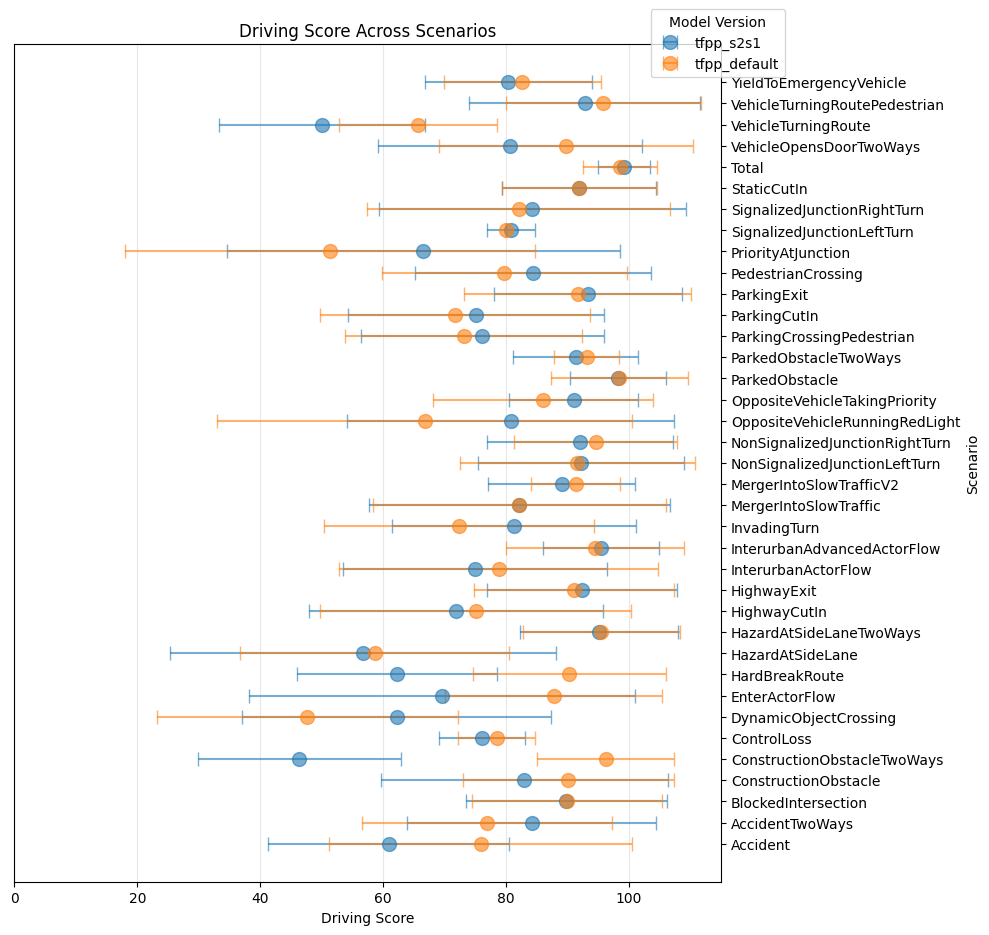

In [55]:
import ujson
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
path_template = "evaluation/{}_routes_validation_model_0030/{}_routes_validation_e0_model_0030/results.json"

files = [
    "tfpp_s2s1",
    "tfpp_default",
    # "tfpp_static_s5s2"
]  # Replace with your files
score_type = "score_composed"  # Choose score_route, score_penalty, etc.
score_types = {
    "score_composed": "Driving Score",
    "score_route": "Route completion",
    "score_penalty": "Infraction score",
}

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]

# Load data into a nested dictionary
scenario_data = defaultdict(list)
file_names = []
for file_name, file_ in [(f, path_template.format(f,f)) for f in files]:
    with open(file_, 'r') as f:
        results = ujson.load(f)
        file_names.append(file_name)
        for scenario_name, scenario in results.items():
            scenario_data[scenario_name].append({
                "File": file_name,
                "Mean": scenario["scores_mean"][score_type],
                "Std": scenario["scores_std"][score_type]
            })

# Create horizontal dot plot with error bars
plt.figure(figsize=(10, len(scenario_data) * 0.2 + 2))  # Adjust height

# Create y-positions for scenarios
scenarios = sorted(scenario_data.keys())
y_pos = np.arange(len(scenarios))

# Plot each scenario
for scenario_idx, (scenario, values) in enumerate(scenario_data.items()):
    for file_idx, file_data in enumerate(values):
        plt.errorbar(
            x=file_data["Mean"],
            y=scenario_idx,
            xerr=file_data["Std"],
            fmt='o',
            capsize=5,
            label=file_data["File"] if scenario_idx == 0 else "",
            markersize=10,
            alpha=0.6,
            color=colors[file_idx]
        )

# Customize plot
plt.yticks(y_pos, scenarios)
plt.xlabel(score_types[score_type])
plt.ylabel("Scenario")
plt.title(f"{score_types[score_type]} Across Scenarios")
plt.grid(True, axis='x', alpha=0.3)

# Move scenario labels to right side
ax = plt.gca()
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()

# Adjust x-axis limits
all_means = [v["Mean"] for scenario in scenario_data.values() for v in scenario]
all_stds = [v["Std"] for scenario in scenario_data.values() for v in scenario]
buffer = max(all_stds) * 1.5 if all_stds else 5
plt.xlim(left=max(0, min(all_means) - buffer), 
        right=min(115, max(all_means) + buffer))  # Assuming scores are 0-100

# Add legend
plt.legend(bbox_to_anchor=(1.1, 1.05), title="Model Version")

plt.tight_layout()
plt.show()

In [26]:
template = "test_{}_2_{}"
template.format("model", "model")

'test_model_2_model'